In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(df.columns.tolist())
print("\nData Types:\n")
print(df.dtypes)
print("\nMissing Values:\n")
print(df.isnull().sum())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:

customerID          0
gender              

In [4]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check unique values in important categorical columns
print("\nChurn values:")
print(df["Churn"].value_counts())

print("\nTotalCharges data type:")
print(df["TotalCharges"].dtype)

Duplicate rows: 0

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Churn values:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

TotalCharges data type:
object


In [5]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Check missing values after conversion
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [6]:
df = df.dropna(subset=["TotalCharges"]).copy()

print("Dataset shape after cleaning:", df.shape)
print("\nRemaining missing values:")
print(df.isnull().sum().sum())

Dataset shape after cleaning: (7032, 21)

Remaining missing values:
0


In [7]:
df = df.drop(columns=["customerID"])

print("Columns after removing customer ID:")
print(df.columns.tolist())

Columns after removing customer ID:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


Churn Distribution:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


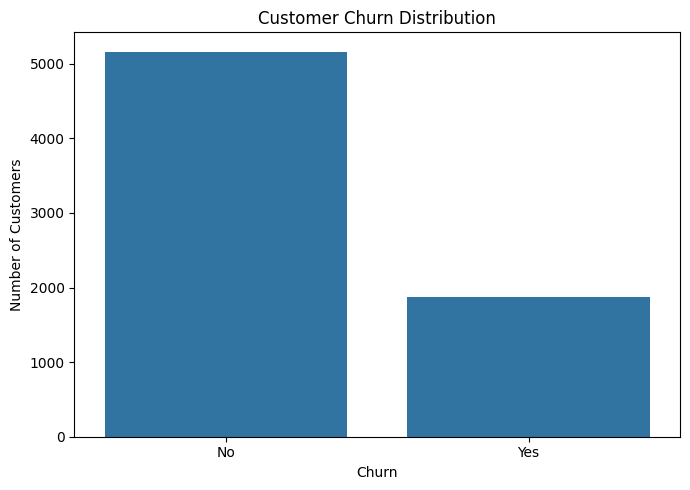

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Churn distribution
print("Churn Distribution:")
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

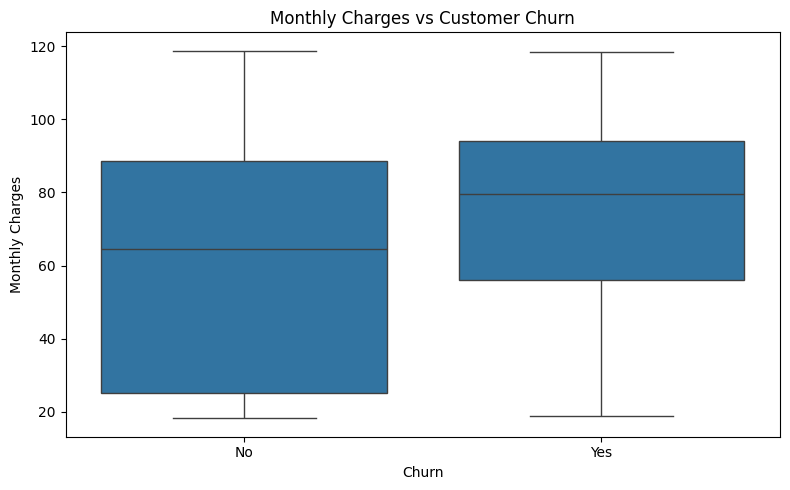

In [9]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

In [10]:
print(
    df.groupby("Churn")["MonthlyCharges"].mean()
)

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64


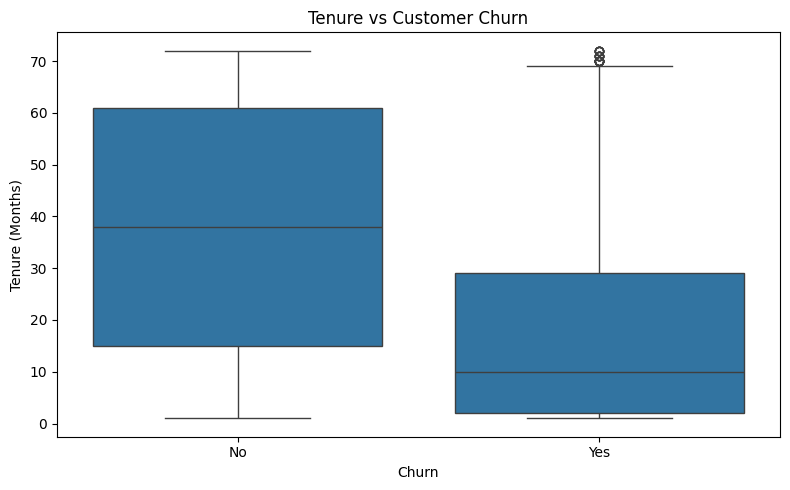

In [11]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.tight_layout()
plt.show()

In [12]:
print(
    df.groupby("Churn")["tenure"].mean()
)

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64


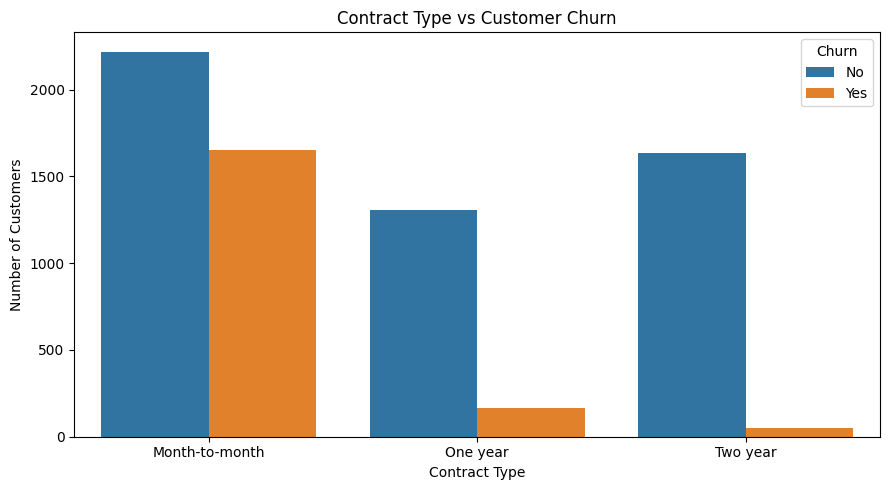

In [13]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type vs Customer Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [14]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn.round(2))

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.72  11.28
Two year        97.15   2.85


In [15]:
# Create a copy for correlation analysis
corr_df = df.copy()

# Convert target to numeric
corr_df["Churn"] = corr_df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Encode categorical variables
categorical_columns = corr_df.select_dtypes(
    include="object"
).columns

corr_df = pd.get_dummies(
    corr_df,
    columns=categorical_columns,
    drop_first=True
)

# Correlation with Churn
churn_correlation = (
    corr_df.corr()["Churn"]
    .sort_values(ascending=False)
)

print("Features most correlated with Churn:")
print(churn_correlation.head(10))

Features most correlated with Churn:
Churn                             1.000000
InternetService_Fiber optic       0.307463
PaymentMethod_Electronic check    0.301455
MonthlyCharges                    0.192858
PaperlessBilling_Yes              0.191454
SeniorCitizen                     0.150541
StreamingTV_Yes                   0.063254
StreamingMovies_Yes               0.060860
MultipleLines_Yes                 0.040033
PhoneService_Yes                  0.011691
Name: Churn, dtype: float64


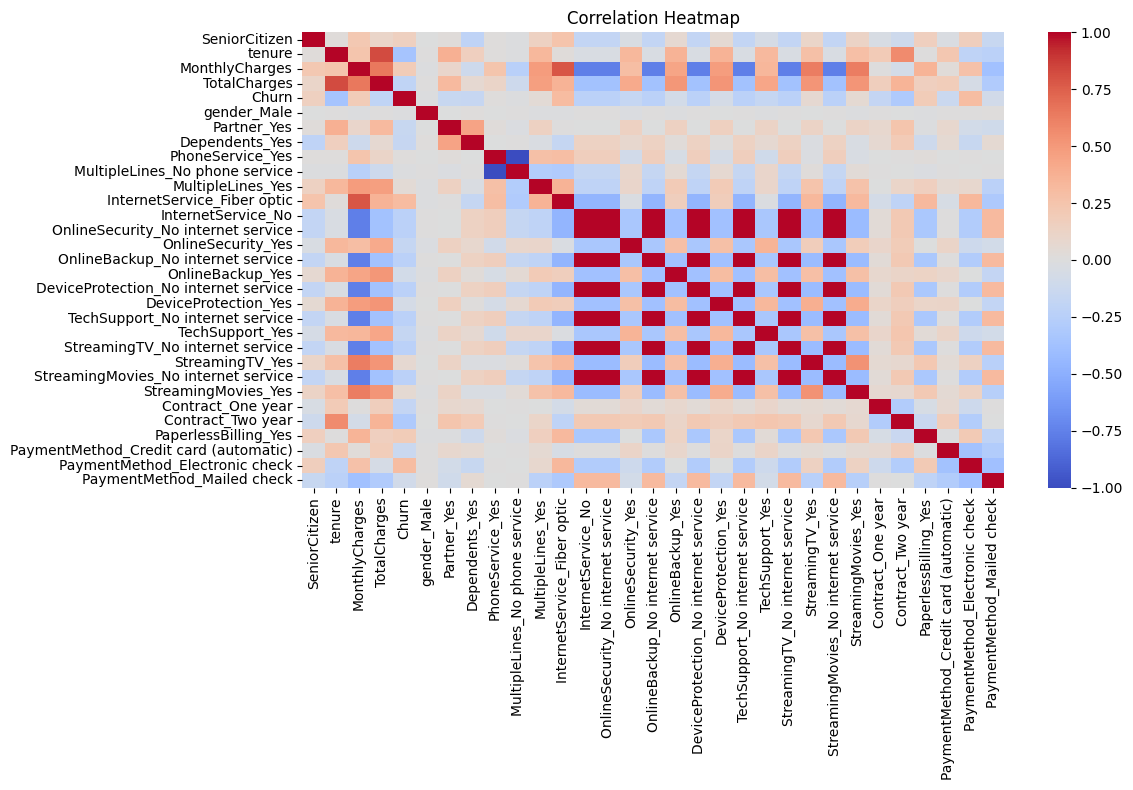

In [16]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [17]:
# Separate features and target

X = df.drop(columns=["Churn"])
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features shape: (7032, 19)
Target shape: (7032,)

Target distribution:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [19]:
# Preprocessing for numerical and categorical features

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining churn distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting churn distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set: (5625, 19)
Testing set: (1407, 19)

Training churn distribution:
Churn
0    0.734
1    0.266
Name: proportion, dtype: float64

Testing churn distribution:
Churn
0    0.734
1    0.266
Name: proportion, dtype: float64


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Create Logistic Regression pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Train
logistic_model.fit(X_train, y_train)

# Predict
y_pred_lr = logistic_model.predict(X_test)

# Evaluation
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("===== LOGISTIC REGRESSION RESULTS =====")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1 Score:  {lr_f1:.4f}")

===== LOGISTIC REGRESSION RESULTS =====
Accuracy:  0.8053
Precision: 0.6515
Recall:    0.5749
F1 Score:  0.6108


In [22]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

print("\nConfusion Matrix:")
print(cm_lr)


Confusion Matrix:
[[918 115]
 [159 215]]


In [23]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree pipeline
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=42,
            max_depth=5
        ))
    ]
)

# Train
decision_tree_model.fit(X_train, y_train)

# Predict
y_pred_dt = decision_tree_model.predict(X_test)

# Evaluation
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print("===== DECISION TREE RESULTS =====")
print(f"Accuracy:  {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall:    {dt_recall:.4f}")
print(f"F1 Score:  {dt_f1:.4f}")

===== DECISION TREE RESULTS =====
Accuracy:  0.7783
Precision: 0.5807
Recall:    0.5963
F1 Score:  0.5884


In [24]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("\nConfusion Matrix:")
print(cm_dt)


Confusion Matrix:
[[872 161]
 [151 223]]


In [25]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest pipeline
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            max_depth=10,
            class_weight="balanced"
        ))
    ]
)

# Train
random_forest_model.fit(X_train, y_train)

# Predict
y_pred_rf = random_forest_model.predict(X_test)

# Evaluation
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("===== RANDOM FOREST RESULTS =====")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")

===== RANDOM FOREST RESULTS =====
Accuracy:  0.7726
Precision: 0.5536
Recall:    0.7460
F1 Score:  0.6355


In [26]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("\nConfusion Matrix:")
print(cm_rf)


Confusion Matrix:
[[808 225]
 [ 95 279]]


In [27]:
# Model comparison

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        lr_f1,
        dt_f1,
        rf_f1
    ]
})

print(results.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.8053     0.6515  0.5749    0.6108
1        Decision Tree    0.7783     0.5807  0.5963    0.5884
2        Random Forest    0.7726     0.5536  0.7460    0.6355


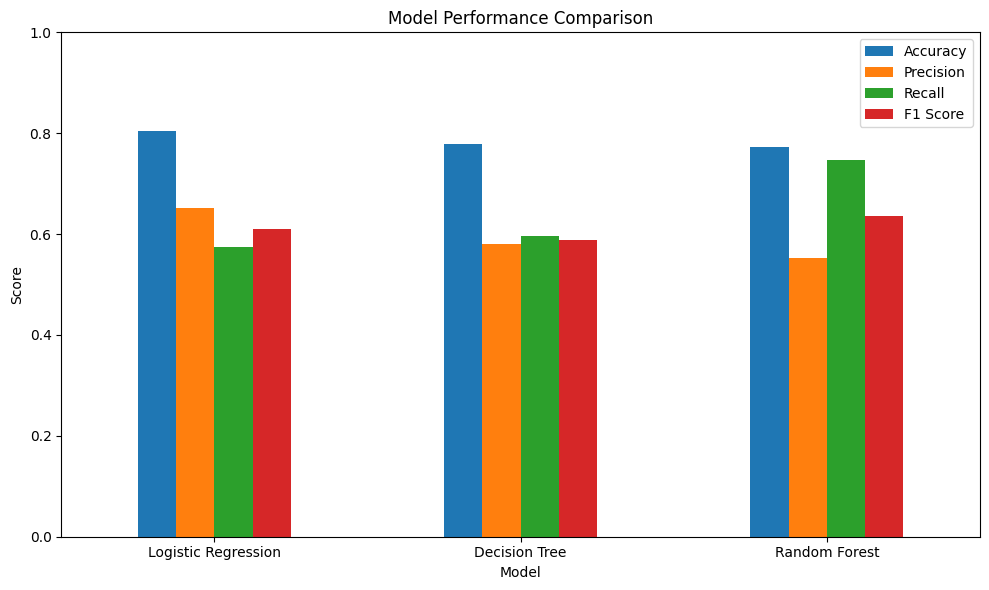

In [28]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# Get feature names after preprocessing

feature_names = random_forest_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get feature importance
importances = random_forest_model.named_steps[
    "classifier"
].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

                                      Feature  Importance
1                                 num__tenure    0.173002
3                           num__TotalCharges    0.144455
2                         num__MonthlyCharges    0.107390
25                     cat__Contract_Two year    0.100932
10           cat__InternetService_Fiber optic    0.062288
28        cat__PaymentMethod_Electronic check    0.050121
24                     cat__Contract_One year    0.044316
13                    cat__OnlineSecurity_Yes    0.035120
19                       cat__TechSupport_Yes    0.022702
26                  cat__PaperlessBilling_Yes    0.018588
16  cat__DeviceProtection_No internet service    0.017969
22   cat__StreamingMovies_No internet service    0.017539
6                         cat__Dependents_Yes    0.015972
15                      cat__OnlineBackup_Yes    0.015522
12    cat__OnlineSecurity_No internet service    0.014894


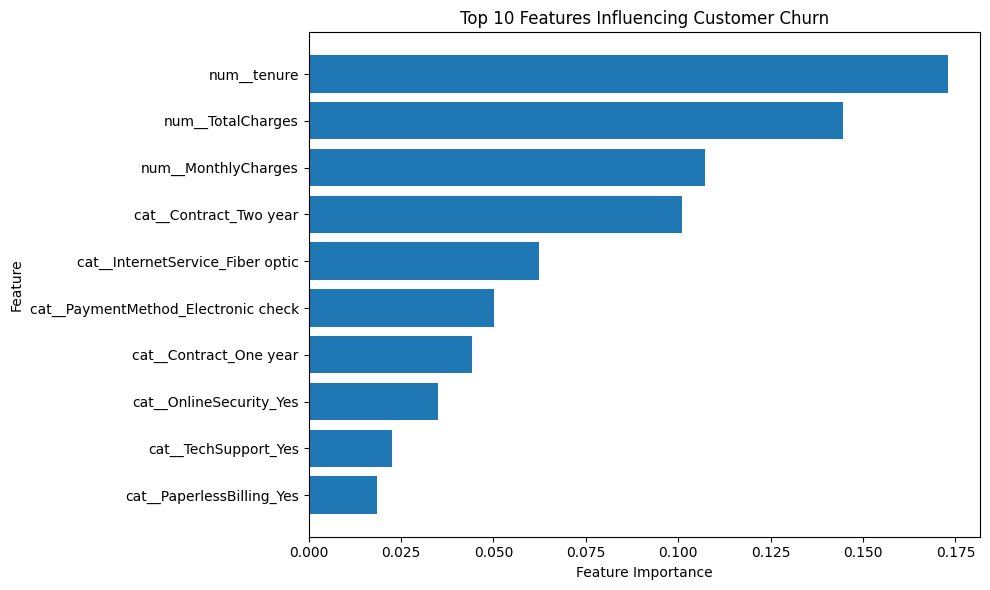

In [30]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(10).sort_values(
    "Importance"
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Features Influencing Customer Churn")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

<Figure size 600x500 with 0 Axes>

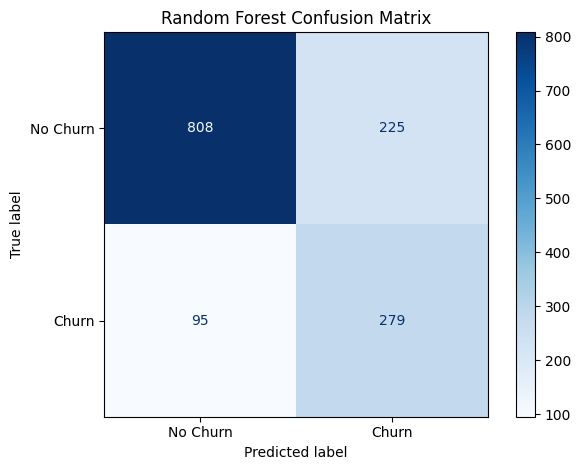

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["No Churn", "Churn"],
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

In [32]:
import joblib

joblib.dump(
    random_forest_model,
    "customer_churn_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [33]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Load trained model
model = joblib.load("customer_churn_model.pkl")

# Page configuration
st.set_page_config(
    page_title="Customer Churn Predictor",
    page_icon="📊",
    layout="wide"
)

st.title("📊 Customer Churn Prediction System")
st.write(
    "Predict whether a customer is likely to churn "
    "based on their profile and service information."
)

st.divider()

# Customer information
st.subheader("👤 Customer Information")

col1, col2, col3 = st.columns(3)

with col1:
    gender = st.selectbox("Gender", ["Male", "Female"])
    senior_citizen = st.selectbox("Senior Citizen", [0, 1])
    partner = st.selectbox("Partner", ["Yes", "No"])
    dependents = st.selectbox("Dependents", ["Yes", "No"])
    tenure = st.number_input(
        "Tenure (months)",
        min_value=0,
        max_value=100,
        value=12
    )

with col2:
    phone_service = st.selectbox("Phone Service", ["Yes", "No"])
    multiple_lines = st.selectbox(
        "Multiple Lines",
        ["Yes", "No", "No phone service"]
    )
    internet_service = st.selectbox(
        "Internet Service",
        ["DSL", "Fiber optic", "No"]
    )
    online_security = st.selectbox(
        "Online Security",
        ["Yes", "No", "No internet service"]
    )
    online_backup = st.selectbox(
        "Online Backup",
        ["Yes", "No", "No internet service"]
    )

with col3:
    device_protection = st.selectbox(
        "Device Protection",
        ["Yes", "No", "No internet service"]
    )
    tech_support = st.selectbox(
        "Tech Support",
        ["Yes", "No", "No internet service"]
    )
    streaming_tv = st.selectbox(
        "Streaming TV",
        ["Yes", "No", "No internet service"]
    )
    streaming_movies = st.selectbox(
        "Streaming Movies",
        ["Yes", "No", "No internet service"]
    )

st.subheader("💳 Billing & Contract Information")

col1, col2, col3 = st.columns(3)

with col1:
    contract = st.selectbox(
        "Contract",
        ["Month-to-month", "One year", "Two year"]
    )

with col2:
    paperless_billing = st.selectbox(
        "Paperless Billing",
        ["Yes", "No"]
    )

with col3:
    payment_method = st.selectbox(
        "Payment Method",
        [
            "Electronic check",
            "Mailed check",
            "Bank transfer (automatic)",
            "Credit card (automatic)"
        ]
    )

col1, col2 = st.columns(2)

with col1:
    monthly_charges = st.number_input(
        "Monthly Charges",
        min_value=0.0,
        value=70.0
    )

with col2:
    total_charges = st.number_input(
        "Total Charges",
        min_value=0.0,
        value=840.0
    )

st.divider()

# Prediction
if st.button("🔮 Predict Churn", use_container_width=True):

    input_data = pd.DataFrame([{
        "gender": gender,
        "SeniorCitizen": senior_citizen,
        "Partner": partner,
        "Dependents": dependents,
        "tenure": tenure,
        "PhoneService": phone_service,
        "MultipleLines": multiple_lines,
        "InternetService": internet_service,
        "OnlineSecurity": online_security,
        "OnlineBackup": online_backup,
        "DeviceProtection": device_protection,
        "TechSupport": tech_support,
        "StreamingTV": streaming_tv,
        "StreamingMovies": streaming_movies,
        "Contract": contract,
        "PaperlessBilling": paperless_billing,
        "PaymentMethod": payment_method,
        "MonthlyCharges": monthly_charges,
        "TotalCharges": total_charges
    }])

    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    st.subheader("Prediction Result")

    if prediction == 1:
        st.error("⚠️ Customer is likely to churn.")
    else:
        st.success("✅ Customer is likely to stay.")

    st.metric(
        "Churn Probability",
        f"{probability * 100:.2f}%"
    )

Writing app.py


In [34]:
%%writefile requirements.txt

streamlit
pandas
scikit-learn
joblib

Writing requirements.txt


In [35]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 56.4 MB/s eta 0:00:00


In [36]:
!streamlit run app.py --server.port 8501 > streamlit.log 2>&1 &

In [37]:
!cat streamlit.log



2026-08-25 13:29:31.372 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.201.144.192:8501



In [38]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

Selecting previously unselected package cloudflared.
(Reading database ... 118422 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.8.2) ...
Setting up cloudflared (2026.8.2) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
!cloudflared tunnel --url http://localhost:8501

2026-08-25T13:31:38Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-08-25T13:31:38Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-08-25T13:31:42Z INF +--------------------------------------------------------------------------------------------+
2026-08-25T13:31:42Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-08-25T13:31:42Z INF |  https://edmonton-surprise-came-wallace.trycloudflare.